In [4]:
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import entropy

from fredapi import Fred

FRED_KEY = "9e67dd28060675ec071dfaa9f650840f"
BEA_KEY  = "5073F933-9D7B-4BB4-ACBB-D59A653AD16C"

fred = Fred(api_key=FRED_KEY)
print("Libraries loaded and APIs connected.")

Libraries loaded and APIs connected.


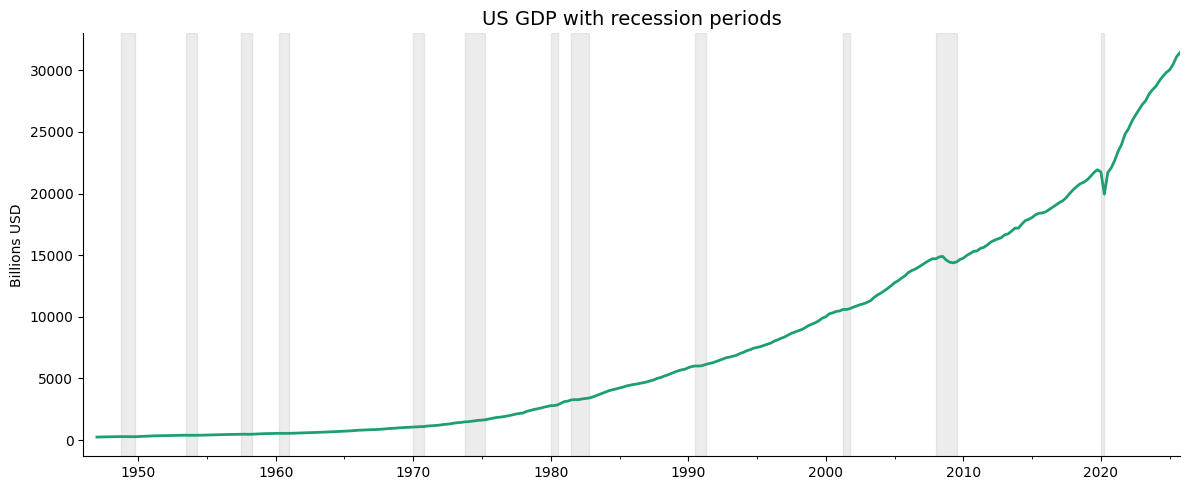

GDP chart saved.


In [5]:
gdp       = fred.get_series('GDP')
recession = fred.get_series('USREC')

fig, ax = plt.subplots(figsize=(12, 5))
gdp.plot(ax=ax, color='#1D9E75', linewidth=2, label='US GDP (billions)')

start = None
for date, val in recession.items():
    if val == 1 and start is None:
        start = date
    elif val == 0 and start is not None:
        ax.axvspan(start, date, alpha=0.15, color='gray')
        start = None

ax.set_title('US GDP with recession periods', fontsize=14, fontweight='normal')
ax.set_ylabel('Billions USD')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/gdp_chart.png', dpi=150)
plt.show()
print("GDP chart saved.")

In [6]:
def get_bea_flows(year, bea_key):
    url = "https://apps.bea.gov/api/data"
    params = {
        "UserID": bea_key,
        "method": "GetData",
        "DataSetName": "InputOutput",
        "TableID": "259",
        "Year": str(year),
        "ResultFormat": "JSON"
    }
    response = requests.get(url, params=params)
    data = response.json()
    rows = data['BEAAPI']['Results'][0]['Data']
    df = pd.DataFrame(rows)
    df['DataValue'] = pd.to_numeric(df['DataValue'], errors='coerce').fillna(0)
    return df

df = get_bea_flows(2006, BEA_KEY)
print("Shape:", df.shape)
print("\nPreview:")
print(df[['RowDescr', 'ColDescr', 'DataValue']].head(5))

Shape: (4499, 10)

Preview:
  RowDescr                                   ColDescr  DataValue
0    Farms                                      Farms      46058
1    Farms  Forestry, fishing, and related activities        667
2    Farms                 Mining, except oil and gas         21
3    Farms              Support activities for mining         15
4    Farms                               Construction       1971


In [7]:
exclude_cols = ['Total use of products', 'Total industry output',
                'Total intermediate', 'Value added']
exclude_rows = ['Total', 'Value added', 'Compensation', 'Gross operating']

def clean_flows(df):
    flows = df[
        ~df['ColDescr'].isin(exclude_cols) &
        ~df['RowDescr'].str.contains('|'.join(exclude_rows), na=False) &
        (df['DataValue'] > 0)
    ].copy()
    
    both = set(flows['RowDescr'].unique()) & set(flows['ColDescr'].unique())
    flows = flows[
        flows['RowDescr'].isin(both) &
        flows['ColDescr'].isin(both)
    ].copy()
    
    total_output = flows.groupby('RowDescr')['DataValue'].sum()
    flows['weight'] = flows.apply(
        lambda row: row['DataValue'] / total_output[row['RowDescr']], axis=1
    )
    return flows

flows = clean_flows(df)
print(f"Clean flows: {len(flows)}")
print(f"Sectors: {flows['RowDescr'].nunique()}")

Clean flows: 3207
Sectors: 64


In [8]:
def build_graph(flows):
    G = nx.DiGraph()
    for _, row in flows[flows['weight'] > 0.01].iterrows():
        G.add_edge(row['RowDescr'], row['ColDescr'], weight=row['weight'])
    return G

G = build_graph(flows)

betweenness = nx.betweenness_centrality(G, weight='weight')
in_degree   = nx.in_degree_centrality(G)
out_degree  = nx.out_degree_centrality(G)

centrality_df = pd.DataFrame({
    'sector':     list(betweenness.keys()),
    'betweenness': list(betweenness.values()),
    'in_degree':  [in_degree[s] for s in betweenness.keys()],
    'out_degree': [out_degree[s] for s in betweenness.keys()],
}).sort_values('betweenness', ascending=False)

print("--- TOP 10 KEYSTONE SECTORS (2006) ---")
print(centrality_df.head(10).to_string(index=False))

--- TOP 10 KEYSTONE SECTORS (2006) ---
                                                        sector  betweenness  in_degree  out_degree
                                                     Utilities     0.091361   0.298507    0.328358
                                             Chemical products     0.081637   0.313433    0.238806
  Rental and leasing services and lessors of intangible assets     0.079150   0.268657    0.462687
                           Administrative and support services     0.066712   0.492537    0.343284
Miscellaneous professional, scientific, and technical services     0.054048   0.582090    0.388060
                                               Wholesale trade     0.049977   0.567164    0.253731
                                     Fabricated metal products     0.046359   0.164179    0.298507
                             Other services, except government     0.039123   0.447761    0.328358
                     Insurance carriers and related activities     0.0

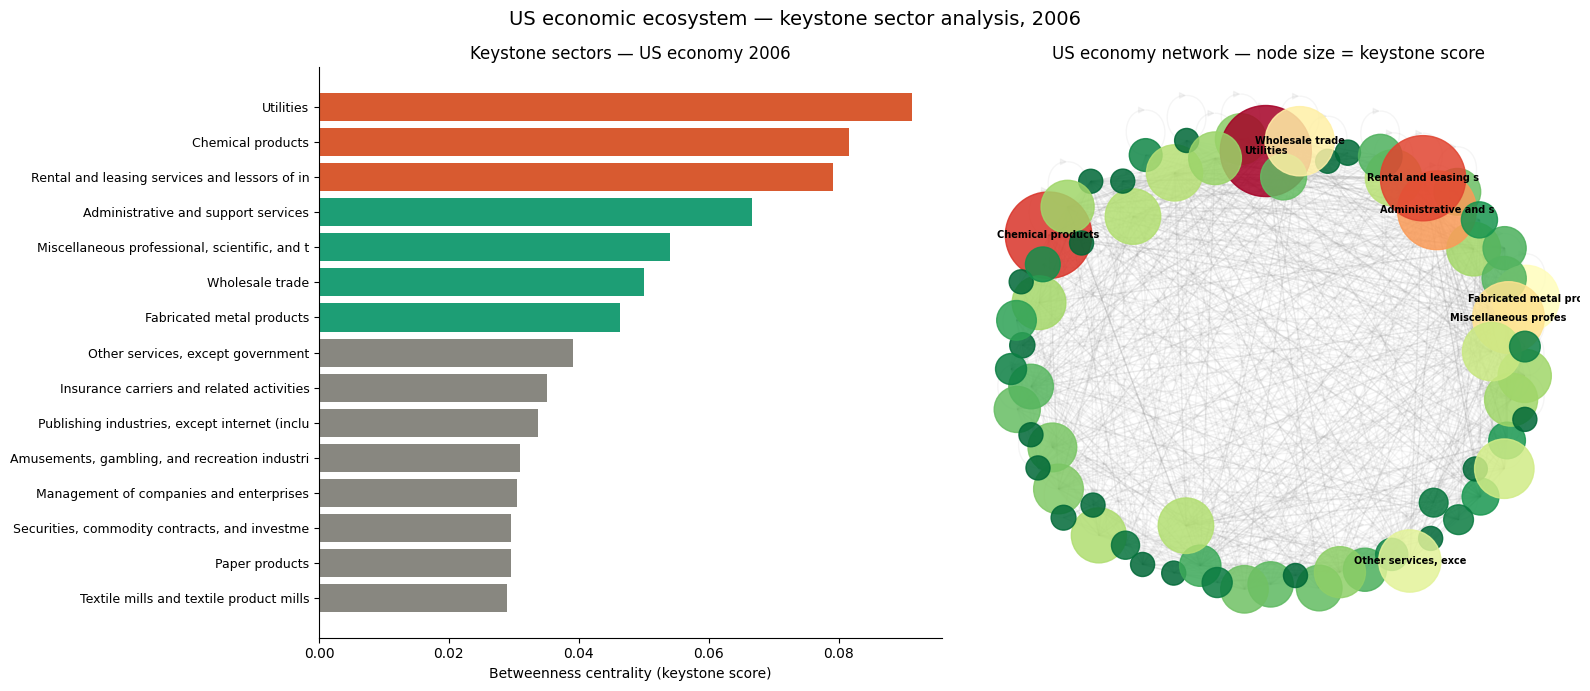

Saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
top15 = centrality_df.head(15).copy()
colors = ['#D85A30' if i < 3 else '#1D9E75' if i < 7 else '#888780'
          for i in range(len(top15))]
ax.barh(range(len(top15)), top15['betweenness'], color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([s[:45] for s in top15['sector']], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Betweenness centrality (keystone score)')
ax.set_title('Keystone sectors — US economy 2006', fontweight='normal', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
pos = nx.spring_layout(G, k=2, seed=42)
node_list = list(G.nodes())
node_betweenness = [betweenness[n] for n in node_list]
max_b = max(node_betweenness)
node_colors = [plt.cm.RdYlGn_r(b / max_b) for b in node_betweenness]
node_sizes  = [300 + 4000 * (b / max_b) for b in node_betweenness]
nx.draw_networkx_edges(G, pos, ax=ax2, alpha=0.08, edge_color='gray', arrows=False)
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)
top8 = set(centrality_df.head(8)['sector'])
labels = {n: n[:20] for n in node_list if n in top8}
nx.draw_networkx_labels(G, pos, labels, ax=ax2, font_size=7, font_weight='bold')
ax2.set_title('US economy network — node size = keystone score',
              fontweight='normal', fontsize=12)
ax2.axis('off')

plt.suptitle('US economic ecosystem — keystone sector analysis, 2006',
             fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/keystone_sectors_2006.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
years = ['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009']

keystone_over_time    = {}
spectral_gap_over_time = {}

for year in years:
    print(f"Pulling {year}...", end=' ')
    df_year    = get_bea_flows(year, BEA_KEY)
    flows_year = clean_flows(df_year)
    G_year     = build_graph(flows_year)
    
    bet = nx.betweenness_centrality(G_year, weight='weight')
    centrality_df_year = pd.DataFrame({
        'sector':     list(bet.keys()),
        'betweenness': list(bet.values()),
    }).sort_values('betweenness', ascending=False)
    keystone_over_time[year] = centrality_df_year
    
    A = nx.to_numpy_array(G_year)
    eigenvalues = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
    spectral_gap_over_time[year] = eigenvalues[0] - eigenvalues[1]
    
    print(f"done. Spectral gap: {spectral_gap_over_time[year]:.4f}")

print("\nAll years complete.")

Pulling 2002... done. Spectral gap: 0.0079
Pulling 2003... done. Spectral gap: 0.0053
Pulling 2004... done. Spectral gap: 0.0085
Pulling 2005... done. Spectral gap: 0.0078
Pulling 2006... done. Spectral gap: 0.0081
Pulling 2007... done. Spectral gap: 0.0052
Pulling 2008... done. Spectral gap: 0.0068
Pulling 2009... done. Spectral gap: 0.0029

All years complete.


In [11]:
ebi_over_time = {}

for year in years:
    df_y   = keystone_over_time[year]
    scores = df_y['betweenness'].values
    scores = scores[scores > 0]
    probs  = scores / scores.sum()
    H      = entropy(probs)
    top3_share = df_y['betweenness'].nlargest(3).sum() / df_y['betweenness'].sum()
    ebi    = H * (1 - top3_share)
    ebi_over_time[year] = {
        'ebi': ebi,
        'entropy': H,
        'top3_concentration': top3_share
    }
    print(f"{year}: EBI={ebi:.4f}  Entropy={H:.4f}  Top3={top3_share:.4f}")

2002: EBI=2.7457  Entropy=3.5406  Top3=0.2245
2003: EBI=2.9289  Entropy=3.5829  Top3=0.1826
2004: EBI=2.8890  Entropy=3.5961  Top3=0.1966
2005: EBI=3.0034  Entropy=3.6636  Top3=0.1802
2006: EBI=2.9120  Entropy=3.6390  Top3=0.1998
2007: EBI=2.8936  Entropy=3.6197  Top3=0.2006
2008: EBI=2.9304  Entropy=3.6053  Top3=0.1872
2009: EBI=2.8808  Entropy=3.5929  Top3=0.1982


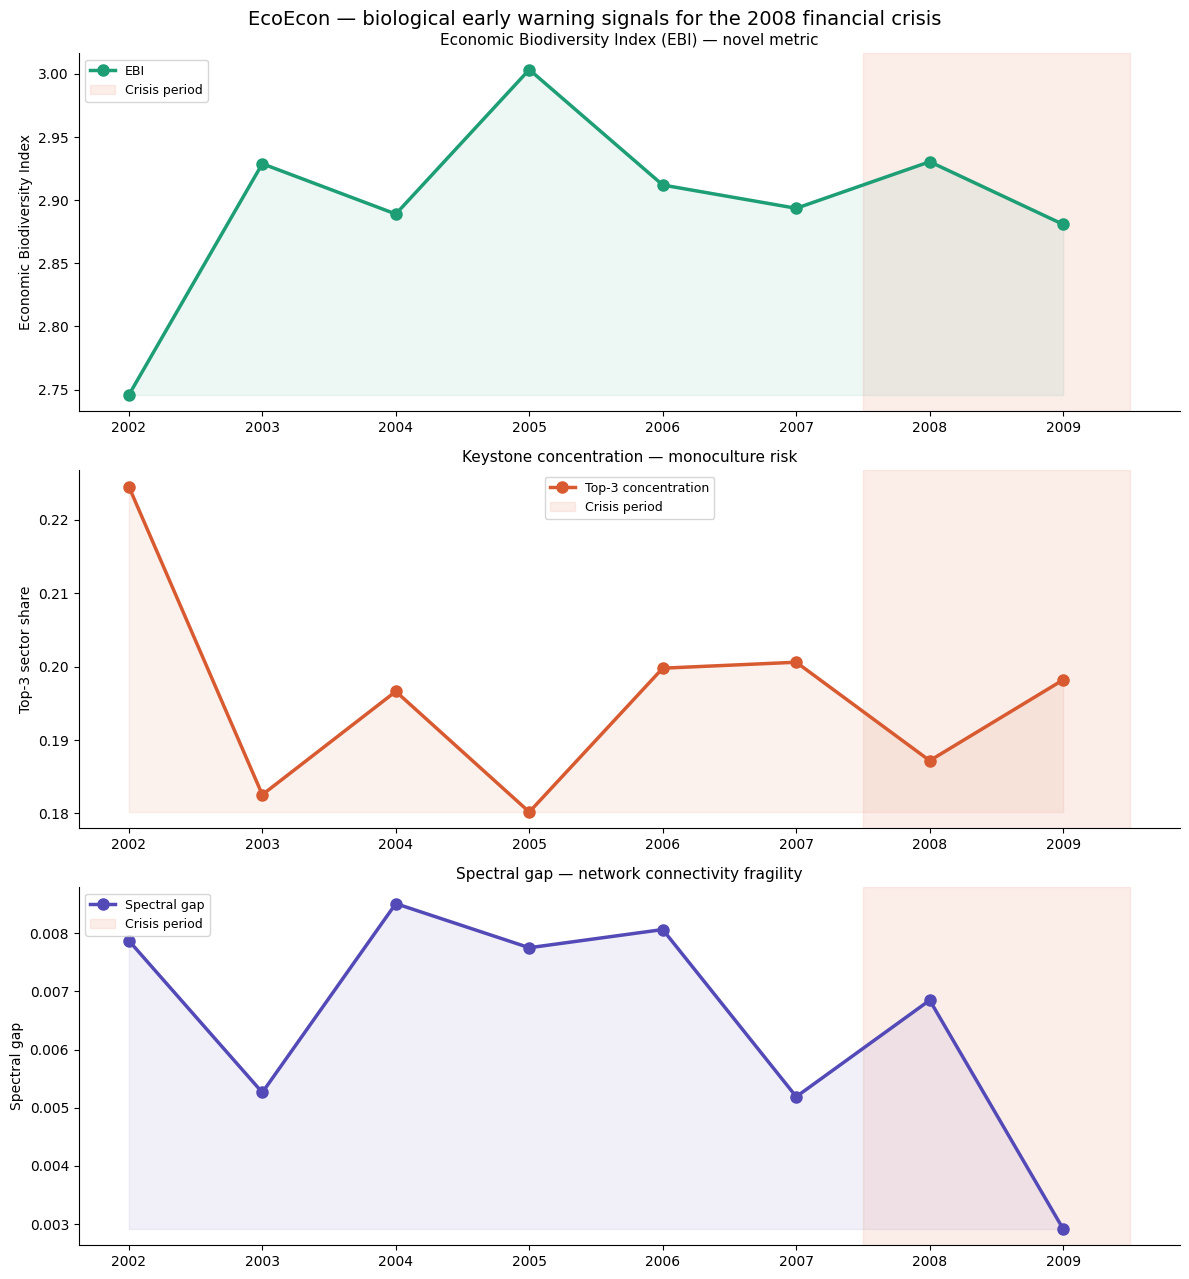

Saved.


In [12]:
years_int = [int(y) for y in years]
ebi_vals  = [ebi_over_time[y]['ebi'] for y in years]
conc_vals = [ebi_over_time[y]['top3_concentration'] for y in years]
spec_vals = [spectral_gap_over_time[y] for y in years]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

def style_ax(ax):
    ax.axvspan(2007.5, 2009.5, alpha=0.10, color='#D85A30', label='Crisis period')
    ax.set_xticks(years_int)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1 = axes[0]
ax1.plot(years_int, ebi_vals, color='#1D9E75', linewidth=2.5,
         marker='o', markersize=8, zorder=3, label='EBI')
ax1.fill_between(years_int, ebi_vals, min(ebi_vals), alpha=0.08, color='#1D9E75')
style_ax(ax1)
ax1.set_ylabel('Economic Biodiversity Index')
ax1.set_title('Economic Biodiversity Index (EBI) — novel metric',
              fontsize=11, fontweight='normal')
ax1.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(years_int, conc_vals, color='#D85A30', linewidth=2.5,
         marker='o', markersize=8, zorder=3, label='Top-3 concentration')
ax2.fill_between(years_int, conc_vals, min(conc_vals), alpha=0.08, color='#D85A30')
style_ax(ax2)
ax2.set_ylabel('Top-3 sector share')
ax2.set_title('Keystone concentration — monoculture risk',
              fontsize=11, fontweight='normal')
ax2.legend(fontsize=9)

ax3 = axes[2]
ax3.plot(years_int, spec_vals, color='#534AB7', linewidth=2.5,
         marker='o', markersize=8, zorder=3, label='Spectral gap')
ax3.fill_between(years_int, spec_vals, min(spec_vals), alpha=0.08, color='#534AB7')
style_ax(ax3)
ax3.set_ylabel('Spectral gap')
ax3.set_title('Spectral gap — network connectivity fragility',
              fontsize=11, fontweight='normal')
ax3.legend(fontsize=9)

plt.suptitle('EcoEcon — biological early warning signals for the 2008 financial crisis',
             fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/ecoceon_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save EBI over time
ebi_df = pd.DataFrame([
    {'year': y, 
     'ebi': ebi_over_time[y]['ebi'],
     'entropy': ebi_over_time[y]['entropy'],
     'top3_concentration': ebi_over_time[y]['top3_concentration'],
     'spectral_gap': spectral_gap_over_time[y]}
    for y in years
])
ebi_df.to_csv('../data/processed/ebi_signals.csv', index=False)

# Save 2006 centrality
centrality_df.to_csv('../data/processed/centrality_2006.csv', index=False)

print("All data saved to data/processed/")
print(ebi_df.to_string(index=False))

All data saved to data/processed/
year      ebi  entropy  top3_concentration  spectral_gap
2002 2.745725 3.540649            0.224514      0.007874
2003 2.928857 3.582926            0.182552      0.005263
2004 2.889034 3.596098            0.196620      0.008511
2005 3.003392 3.663553            0.180197      0.007752
2006 2.912006 3.639030            0.199785      0.008065
2007 2.893572 3.619657            0.200595      0.005190
2008 2.930440 3.605317            0.187189      0.006849
2009 2.880815 3.592919            0.198196      0.002915
